## **toy demonstration: embedding -> coupling -> Marcus rate -> Lindblad photocurrent**

The four steps proposed above are implemented end-to-end here using **two ethylene
molecules held in a face-to-face pi-stack** as a minimal stand-in for a donor/acceptor
chromophore pair (e.g. a chlorophyll special pair).

In [15]:
!pip install qiskit qiskit-aer qiskit-nature qiskit-algorithms pyscf matplotlib pandas --quiet

In [16]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import transpile
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import efficient_su2
from qiskit.circuit.library import real_amplitudes

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM

from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import SLSQP, COBYLA

from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit_aer.primitives import EstimatorV2 as AerEstimatorV2, SamplerV2 as AerSamplerV2

##**Step 1: toy embedding**

In [17]:
HARTREE_TO_EV = 27.211386245988
mapper = JordanWignerMapper()
basis_gates = ["cx", "id", "rz", "sx", "x"]

def run_vqe(ansatz, problem, mapper, optimizer, initial_point=None, estimator=None):
    estimator = estimator or StatevectorEstimator()
    history = []
    def callback(eval_count, params, value, meta):
        history.append(value)
    vqe = VQE(estimator, ansatz, optimizer, callback=callback)
    vqe.initial_point = (initial_point if initial_point is not None
                          else np.zeros(ansatz.num_parameters))
    solver = GroundStateEigensolver(mapper, vqe)
    result = solver.solve(problem)
    return result, history, vqe

In [18]:
from pyscf import gto, scf

_monomer = {
    "C1": np.array([0.0,  0.0,  0.6695]), "C2": np.array([0.0,  0.0, -0.6695]),
    "H1": np.array([0.0,  0.9289,  1.2321]), "H2": np.array([0.0, -0.9289,  1.2321]),
    "H3": np.array([0.0,  0.9289, -1.2321]), "H4": np.array([0.0, -0.9289, -1.2321]),
}

def dimer_geometry(d=3.6):
    order = ["C1", "C2", "H1", "H2", "H3", "H4"]
    lines = []
    for shift in (-d / 2, d / 2):
        for name in order:
            x, y, z = _monomer[name]
            lines.append(f"{name[0]} {x+shift:.6f} {y:.6f} {z:.6f}")
    return "; ".join(lines)

mol = gto.M(atom=dimer_geometry().replace("; ", "\n"), basis="sto-3g", charge=0, spin=0, unit="Angstrom")
mf = scf.RHF(mol).run(verbose=0)
homo_idx = mol.nelectron // 2 - 1
print("Frontier orbital energies (Ha):")
for i in range(homo_idx - 1, homo_idx + 3):
    print(f"  {i}: {mf.mo_energy[i]: .6f}")
# Orbitals 14,15 (occupied) and 16,17 (virtual) are the symmetric/antisymmetric
# combinations of the two monomers' pi and pi* orbitals.

full_problem_dimer = PySCFDriver(atom=dimer_geometry(), basis="sto-3g", charge=0, spin=0).run()
as_problem_dimer = ActiveSpaceTransformer(
    num_electrons=4, num_spatial_orbitals=4, active_orbitals=[14, 15, 16, 17]
).transform(full_problem_dimer)
print(f"Embedded active space: {as_problem_dimer.num_spatial_orbitals} orbitals, "
      f"{as_problem_dimer.num_particles} particles")

Frontier orbital energies (Ha):
  14: -0.330033
  15: -0.310285
  16:  0.312762
  17:  0.327457
Embedded active space: 4 orbitals, (2, 2) particles


##**Step 2: coupling via QEOM**

In [19]:
hf_dimer = HartreeFock(as_problem_dimer.num_spatial_orbitals, as_problem_dimer.num_particles, mapper)
ansatz_dimer = UCCSD(as_problem_dimer.num_spatial_orbitals, as_problem_dimer.num_particles,
                      mapper, initial_state=hf_dimer)
ansatz_dimer_t = transpile(ansatz_dimer, basis_gates=basis_gates, optimization_level=1)

fast_estimator = AerEstimatorV2(options={"default_precision": 0.0})
gs_result_dimer, _, vqe_dimer = run_vqe(ansatz_dimer_t, as_problem_dimer, mapper,
                                         SLSQP(maxiter=200), estimator=fast_estimator)
gse_dimer = GroundStateEigensolver(mapper, vqe_dimer)
qeom_dimer = QEOM(gse_dimer, AerEstimatorV2(options={"default_precision": 0.0}), "s").solve(as_problem_dimer)

dimer_energies_eV = (np.array(qeom_dimer.computed_energies) - qeom_dimer.computed_energies[0]) * HARTREE_TO_EV
print("All QEOM energies (eV):", np.round(dimer_energies_eV, 4))
J_coupling_eV = (dimer_energies_eV[2] - dimer_energies_eV[1]) / 2
print(f"Lowest excited states (eV): {np.round(dimer_energies_eV[:3], 4)}")
print(f"Extracted coupling J = H_DA = {J_coupling_eV*1000:.3f} meV")

All QEOM energies (eV): [ 0.      4.7663  4.7835 13.8835 14.3173 16.0445 16.0461 16.0622 16.1327]
Lowest excited states (eV): [0.     4.7663 4.7835]
Extracted coupling J = H_DA = 8.559 meV


In [20]:
# Extract relative energies in eV and the S^2 values for all states
energies_eV = (np.array(qeom_dimer.computed_energies) - qeom_dimer.computed_energies[0]) * HARTREE_TO_EV
s2_values = qeom_dimer.total_angular_momentum

print("--- QEOM State Spins ---")
for i, (energy, s2) in enumerate(zip(energies_eV, s2_values)):
    # The S^2 expectation value follows S(S+1)
    if s2 is None:
        print(f"State {i}: S^2 observable not evaluated.")
        continue
        
    if np.isclose(s2, 0.0, atol=0.2):
        spin_label = "Singlet (S=0)"
    elif np.isclose(s2, 2.0, atol=0.2):
        spin_label = "Triplet (S=1)"
    elif np.isclose(s2, 0.75, atol=0.2):
        spin_label = "Doublet (S=1/2)"
    else:
        spin_label = "Mixed / Spin-Contaminated"
        
    print(f"State {i}: Energy Gap = {energy:.4f} eV | S^2 = {s2:.4f} ({spin_label})")

--- QEOM State Spins ---
State 0: Energy Gap = 0.0000 eV | S^2 = 0.0000 (Singlet (S=0))
State 1: Energy Gap = 4.7663 eV | S^2 = 0.0000 (Singlet (S=0))
State 2: Energy Gap = 4.7835 eV | S^2 = 0.0000 (Singlet (S=0))
State 3: Energy Gap = 13.8835 eV | S^2 = 0.0000 (Singlet (S=0))
State 4: Energy Gap = 14.3173 eV | S^2 = 0.0000 (Singlet (S=0))
State 5: Energy Gap = 16.0445 eV | S^2 = 0.0000 (Singlet (S=0))
State 6: Energy Gap = 16.0461 eV | S^2 = 0.0000 (Singlet (S=0))
State 7: Energy Gap = 16.0622 eV | S^2 = 0.0000 (Singlet (S=0))
State 8: Energy Gap = 16.1327 eV | S^2 = 0.0000 (Singlet (S=0))


##**Step 3: Marcus rate**

k_ET at dG0 = -0.10 eV: 1.025e+12 s^-1
Marcus peak at dG0 = -0.247 eV (theory: -lambda = -0.25 eV)


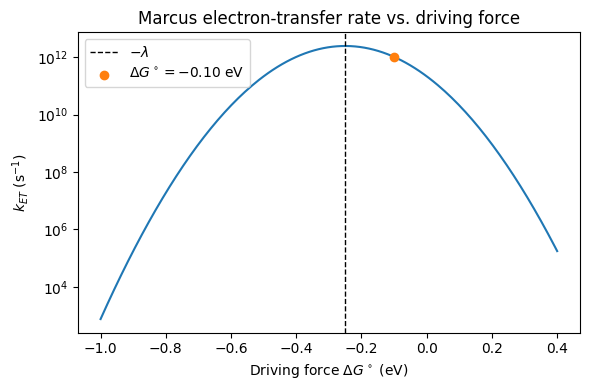

In [21]:
HBAR, KB, EV_TO_J, T_KELVIN = 1.054571817e-34, 1.380649e-23, 1.602176634e-19, 298.0
H_DA = J_coupling_eV * EV_TO_J
LAMBDA_EV = 0.25          # illustrative literature value (Marcus & Sutin, 1985)
lam = LAMBDA_EV * EV_TO_J

def marcus_rate(dG0_eV: float) -> float:
    dG0 = dG0_eV * EV_TO_J
    prefactor = (2 * np.pi / HBAR) * H_DA**2 / np.sqrt(4 * np.pi * lam * KB * T_KELVIN)
    return prefactor * np.exp(-(dG0 + lam)**2 / (4 * lam * KB * T_KELVIN))

dG0_range = np.linspace(-1.0, 0.4, 200)
rates = marcus_rate(dG0_range)
k_ET = marcus_rate(-0.10)
print(f"k_ET at dG0 = -0.10 eV: {k_ET:.3e} s^-1")
print(f"Marcus peak at dG0 = {dG0_range[np.argmax(rates)]:.3f} eV (theory: -lambda = {-LAMBDA_EV} eV)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(dG0_range, rates)
ax.axvline(-LAMBDA_EV, color="k", ls="--", lw=1, label=r"$-\lambda$")
ax.scatter([-0.10], [k_ET], color="C1", zorder=5, label=r"$\Delta G^\circ=-0.10$ eV")
ax.set_xlabel(r"Driving force $\Delta G^\circ$ (eV)"); ax.set_ylabel(r"$k_{ET}$ (s$^{-1}$)")
ax.set_title("Marcus electron-transfer rate vs. driving force")
ax.legend(); plt.tight_layout(); plt.show()

##**Step 4: Lindblad kinetics → photocurrent yield**

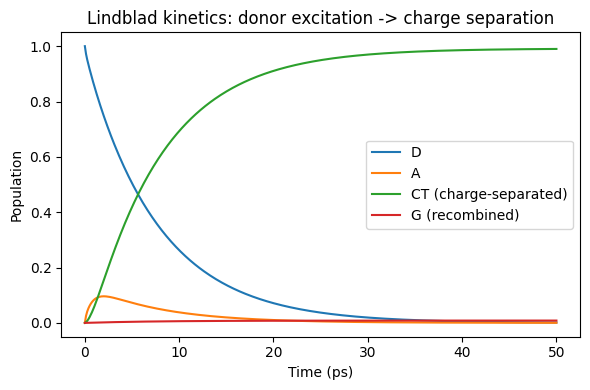

Final populations: D=0.0014, A=0.0002, CT=0.9900, G=0.0084
Internal quantum efficiency (charge-separation yield): 99.16%


In [22]:
from scipy.integrate import solve_ivp

dim = 4
D, A, CT, G = 0, 1, 2, 3
E_D_eV, E_A_eV = 0.0, -0.10
k_loss = 1.0e9
gamma_deph = 1.0e13
HBAR_eVs = 6.582119569e-16

H = np.zeros((dim, dim), dtype=complex)
H[D, D], H[A, A] = E_D_eV, E_A_eV
H[D, A] = H[A, D] = J_coupling_eV

L_ops = []
L_ct = np.zeros((dim, dim), dtype=complex); L_ct[CT, A] = np.sqrt(k_ET)
L_ops.append(L_ct)
for site in (D, A):
    L_loss = np.zeros((dim, dim), dtype=complex); L_loss[G, site] = np.sqrt(k_loss)
    L_deph = np.zeros((dim, dim), dtype=complex); L_deph[site, site] = np.sqrt(gamma_deph)
    L_ops += [L_loss, L_deph]

def drho_dt(t, rho_flat):
    rho = rho_flat.reshape(dim, dim)
    comm = -1j / HBAR_eVs * (H @ rho - rho @ H)
    diss = np.zeros_like(rho)
    for L in L_ops:
        Ld = L.conj().T
        diss += L @ rho @ Ld - 0.5 * (Ld @ L @ rho + rho @ Ld @ L)
    return (comm + diss).flatten()

rho0 = np.zeros((dim, dim), dtype=complex)
rho0[D, D] = 1.0
t_eval = np.linspace(0, 5e-11, 400)
sol = solve_ivp(drho_dt, (0, 5e-11), rho0.flatten(), t_eval=t_eval, method="RK45",
                 rtol=1e-8, atol=1e-10)
pops = np.real(sol.y.reshape(dim, dim, -1))
labels_pop = ["D", "A", "CT (charge-separated)", "G (recombined)"]

fig, ax = plt.subplots(figsize=(6, 4))
for i, lbl in enumerate(labels_pop):
    ax.plot(t_eval * 1e12, pops[i, i, :], label=lbl)
ax.set_xlabel("Time (ps)"); ax.set_ylabel("Population")
ax.set_title("Lindblad kinetics: donor excitation -> charge separation")
ax.legend(); plt.tight_layout(); plt.show()

quantum_yield = pops[CT, CT, -1] / (pops[CT, CT, -1] + pops[G, G, -1])
print(f"Final populations: D={pops[D,D,-1]:.4f}, A={pops[A,A,-1]:.4f}, "
      f"CT={pops[CT,CT,-1]:.4f}, G={pops[G,G,-1]:.4f}")
print(f"Internal quantum efficiency (charge-separation yield): {quantum_yield*100:.2f}%")